# 2-Bin TF-IDF Model: Trenches vs. Skill/Coverage

Positions are grouped into two football-role bins and a completely separate pipeline is fitted per bin:

| Bin | Positions |
|---|---|
| **Trenches** | OL, DT, EDGE, LB |
| **Skill/Coverage** | QB, WR, RB, DB, TE, SPECIAL |

Each bin gets its own `YearNormalizedTfidf` + numeric/categorical features + Random Forest, matching the preprocessing pipeline from `legacy_annual_tf_idf.ipynb` exactly.

Comparison:
- **Baseline**: grade + Pos_Group (logistic regression)
- **Legacy corpus TF-IDF**: whole-corpus model from legacy notebook
- **2-bin model**: this notebook

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import average_precision_score

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

## Data loading

In [2]:
ROOT = Path('..')
path = ROOT / 'data' / 'processed' / 'draft_enriched_with_contracts.csv'
raw = pd.read_csv(path, low_memory=False)

df = raw.query('2014 <= year <= 2025').copy()
text_cols = ['overview', 'strengths', 'weaknesses']
df[text_cols] = df[text_cols].fillna('')
df['scouting_text'] = (
    df[text_cols].agg(' '.join, axis=1)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
numeric_cols = ['grade', 'total_score', 'production_score', 'athleticism_score']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
df['Pos_Group'] = df['Pos_Group'].fillna('UNKNOWN')
df['made_it_contract'] = df['made_it_contract'].where(df.year <= 2021)
df = df.loc[(df['grade'] > 0)].copy()
print(f'Rows loaded: {len(df)}')

Rows loaded: 5477


## Preprocessing

Identical to `legacy_annual_tf_idf.ipynb`: NFL stopwords, lemmatization, phrase blocklist, OVR/STR/WKN section tags.

In [3]:
KEEP_WORDS = {
    'high', 'low', 'heavy', 'light', 'deep', 'short', 'long', 'wide',
    'hard', 'soft', 'strong', 'quick', 'good', 'great', 'up', 'down',
    'off', 'out', 'over', 'through', 'above', 'below',
}
CUSTOM_STOPS = {
    'prospect', 'player', 'players', 'show', 'shows', 'need', 'needs',
    'ability', 'also', 'often', 'must', 'well', 'still', 'use', 'get',
    'make', 'look', 'help', 'work', 'time', 'year', 'team', 'game',
    'continue', 'develop', 'development', 'nfl', 'draft', 'college',
    'level', 'type', 'project', 'potential', 'upside', 'ceiling',
}
PHRASE_BLOCKLIST = [
    'undrafted free agent', 'practice squad', 'free agent', 'early starter',
    'pro bowl', 'late round', 'undrafted free', 'make roster', 'rostered',
]
_base_stops = set(stopwords.words('english'))
NFL_STOPWORDS = (_base_stops - KEEP_WORDS) | CUSTOM_STOPS
_lemmatizer = WordNetLemmatizer()

def nfl_preprocess_no_stitch(text: str) -> str:
    """NFL-aware preprocessing without compound phrase stitching.

    Steps: lowercase → strip outcome-leaking phrases → normalize hyphens →
    alpha-only → tokenize → NFL stopwords → lemmatize.
    TF-IDF bigrams (ngram_range=(1,2)) capture collocations like 'pass rush'
    naturally without needing to stitch them into 'pass_rush' tokens.
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text.lower()
    for phrase in sorted(PHRASE_BLOCKLIST, key=len, reverse=True):
        text = text.replace(phrase, ' ')
    text = re.sub(r'[-\u2013\u2014]', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in NFL_STOPWORDS and len(t) > 1]
    tokens = [_lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

_tag_prefix = {'overview': 'OVR', 'strengths': 'STR', 'weaknesses': 'WKN'}
for col, prefix in _tag_prefix.items():
    df[f'{col}_clean'] = df[col].apply(nfl_preprocess_no_stitch)

def _build_tagged_clean(row):
    parts = [f"{prefix}: {row[f'{col}_clean']}"
             for col, prefix in _tag_prefix.items()
             if str(row[f'{col}_clean']).strip()]
    return ' '.join(parts)

df['scouting_text_tagged'] = df.apply(_build_tagged_clean, axis=1)
df = df.loc[df['scouting_text_tagged'].str.strip() != ''].copy()

token_counts = df['scouting_text_tagged'].str.split().str.len()
print(f'Players after preprocessing: {len(df)}')
print(f'Tokens/player — median: {int(token_counts.median())}, mean: {token_counts.mean():.0f}')

Players after preprocessing: 5321
Tokens/player — median: 133, mean: 135


## Position bins

Two bins based on football role and scouting language patterns.

In [4]:
BIN_MAP = {
    'OL': 'trenches', 'DT': 'trenches', 'EDGE': 'trenches', 'LB': 'trenches',
    'QB': 'skill',    'WR': 'skill',    'RB':   'skill',
    'DB': 'skill',    'TE': 'skill',    'SPECIAL': 'skill',
}
df['pos_bin'] = df['Pos_Group'].map(BIN_MAP).fillna('skill')

train_mask = df.year.between(2014, 2021) & df.made_it_contract.notna()
train_df = df.loc[train_mask].copy()
train_df['made_it_contract'] = train_df['made_it_contract'].astype(int)
y_train = train_df['made_it_contract']

print('Bin sizes (labeled 2014-2021):')
print(train_df.groupby('pos_bin')['Pos_Group'].value_counts().to_string())

Bin sizes (labeled 2014-2021):
pos_bin   Pos_Group
skill     DB           570
          WR           436
          RB           285
          TE           173
          QB           132
          SPECIAL       67
trenches  OL           510
          EDGE         406
          DT           256
          LB           218


## YearNormalizedTfidf

Identical to the legacy notebook: fits a TF-IDF vectorizer, computes per-year mean vectors, and subtracts them at transform time to remove draft-year language drift.

In [5]:
class YearNormalizedTfidf(BaseEstimator, TransformerMixin):
    def __init__(self, text_column='scouting_text_tagged', year_column='year', vectorizer_params=None):
        self.text_column = text_column
        self.year_column = year_column
        self.vectorizer_params = vectorizer_params or {}
        self.vectorizer = TfidfVectorizer(**self.vectorizer_params)

    def fit(self, X, y=None):
        texts = X[self.text_column].fillna('')
        years = X[self.year_column].astype(int).values
        tfidf = self.vectorizer.fit_transform(texts)
        arr = tfidf.toarray()
        self.year_means_ = {}
        for year in np.unique(years):
            mask = years == year
            if mask.sum():
                self.year_means_[year] = arr[mask].mean(axis=0)
        self.global_mean_ = arr.mean(axis=0)
        return self

    def transform(self, X):
        texts = X[self.text_column].fillna('')
        years = X[self.year_column].astype(int).values
        tfidf = self.vectorizer.transform(texts)
        arr = tfidf.toarray()
        adjusted = arr.copy()
        for year, mean in self.year_means_.items():
            mask = years == year
            if mask.sum():
                adjusted[mask] -= mean
        unseen_mask = ~np.isin(years, list(self.year_means_.keys()))
        if unseen_mask.any():
            adjusted[unseen_mask] -= self.global_mean_
        return adjusted

## Pipelines

Three pipelines compared:
1. **Baseline**: grade + Pos_Group + year → logistic regression
2. **Legacy corpus TF-IDF**: whole-corpus YearNormalizedTfidf + meta → Random Forest
3. **2-bin model**: separate pipeline per bin (trenches / skill)

In [6]:
numeric_features = ['grade', 'total_score', 'production_score', 'athleticism_score', 'year']
cat_features = ['Pos_Group']
vectorizer_params = dict(max_features=500, ngram_range=(1, 2), min_df=3, sublinear_tf=True)

class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, cols): self.cols = cols
    def fit(self, X, y=None): return self
    def transform(self, X): return X[self.cols]

class DFTransformer(BaseEstimator, TransformerMixin):
    """Wraps a ColumnTransformer so FeatureUnion can pass a full DataFrame."""
    def __init__(self, ct): self.ct = ct
    def fit(self, X, y=None): self.ct.fit(X, y); return self
    def transform(self, X): return self.ct.transform(X)

# ── Baseline ─────────────────────────────────────────────────────────────────
baseline_pipe = Pipeline([
    ('preproc', ColumnTransformer([
        ('grade', StandardScaler(), ['grade']),
        ('pos',   OneHotEncoder(handle_unknown='ignore'), ['Pos_Group']),
        ('year',  StandardScaler(), ['year']),
    ], remainder='drop')),
    ('lr', LogisticRegression(max_iter=2000, solver='liblinear')),
])

# ── Legacy corpus TF-IDF (reference) ─────────────────────────────────────────
meta_pre = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('pos', OneHotEncoder(handle_unknown='ignore'), cat_features),
], remainder='drop')

legacy_pipe = Pipeline([
    ('features', FeatureUnion([
        ('text', Pipeline([
            ('sel', ColumnSelector(['scouting_text_tagged', 'year'])),
            ('yn',  YearNormalizedTfidf(
                text_column='scouting_text_tagged',
                vectorizer_params=vectorizer_params,
            )),
        ])),
        ('meta', DFTransformer(meta_pre)),
    ])),
    ('rf', RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42, n_jobs=-1)),
])

# ── 2-bin pipeline builder ────────────────────────────────────────────────────
def build_bin_pipe():
    """One full pipeline for a single bin — YearNormalizedTfidf + meta + RF."""
    bin_meta = ColumnTransformer([
        ('num', StandardScaler(), numeric_features),
        ('pos', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ], remainder='drop')
    return Pipeline([
        ('features', FeatureUnion([
            ('text', Pipeline([
                ('sel', ColumnSelector(['scouting_text_tagged', 'year'])),
                ('yn',  YearNormalizedTfidf(
                    text_column='scouting_text_tagged',
                    vectorizer_params=vectorizer_params,
                )),
            ])),
            ('meta', DFTransformer(bin_meta)),
        ])),
        ('rf', RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42, n_jobs=-1)),
    ])

print('Pipelines defined.')

Pipelines defined.


## Cross-validation

PR-AUC (average precision) across 5 stratified folds. The 2-bin model uses per-fold OOF predictions stitched across both bins.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

positive_rate = y_train.mean()
desired_rate = 0.3
pos_weight = desired_rate / positive_rate
neg_weight = (1 - desired_rate) / (1 - positive_rate)
baseline_weights = y_train * pos_weight + (1 - y_train) * neg_weight

print(f'Positive rate: {positive_rate:.2%}  |  pos_weight: {pos_weight:.2f}  neg_weight: {neg_weight:.2f}')

Positive rate: 32.72%  |  pos_weight: 0.92  neg_weight: 1.04


In [8]:
print('Running CV — this may take a minute...\n')

# ── Baseline ──────────────────────────────────────────────────────────────────
baseline_scores = []
for tr, te in cv.split(train_df, y_train):
    est = clone(baseline_pipe)
    est.fit(train_df.iloc[tr], y_train.iloc[tr], lr__sample_weight=baseline_weights.iloc[tr])
    baseline_scores.append(average_precision_score(
        y_train.iloc[te], est.predict_proba(train_df.iloc[te])[:, 1]
    ))

# ── Legacy corpus TF-IDF ──────────────────────────────────────────────────────
legacy_scores = cross_val_score(legacy_pipe, train_df, y_train, cv=cv, scoring='average_precision')

# ── 2-bin OOF ─────────────────────────────────────────────────────────────────
oof_bin = np.zeros(len(train_df))
for tr_idx, te_idx in cv.split(train_df, y_train):
    tr_X = train_df.iloc[tr_idx]
    te_X = train_df.iloc[te_idx].reset_index(drop=True)
    tr_y = y_train.iloc[tr_idx]

    bin_pipes = {}
    for bin_name, grp in tr_X.groupby('pos_bin'):
        grp_y = tr_y.loc[grp.index]
        if grp_y.nunique() < 2:
            continue
        pipe = build_bin_pipe()
        pipe.fit(grp, grp_y)
        bin_pipes[bin_name] = pipe

    fold_preds = np.zeros(len(te_X))
    for bin_name, grp in te_X.groupby('pos_bin'):
        rows = grp.index.tolist()
        if bin_name in bin_pipes:
            fold_preds[rows] = bin_pipes[bin_name].predict_proba(grp)[:, 1]
    oof_bin[te_idx] = fold_preds

bin_prauc = average_precision_score(y_train, oof_bin)

print(f'Baseline (grade + pos):      {np.mean(baseline_scores):.3f} ± {np.std(baseline_scores):.3f}')
print(f'Legacy corpus TF-IDF + RF:   {legacy_scores.mean():.3f} ± {legacy_scores.std():.3f}')
print(f'2-bin TF-IDF + RF:           {bin_prauc:.3f}')

Running CV — this may take a minute...

Baseline (grade + pos):      0.567 ± 0.024
Legacy corpus TF-IDF + RF:   0.563 ± 0.019
2-bin TF-IDF + RF:           0.548


## Per-bin PR-AUC breakdown

Uses OOF predictions to show where each bin contributes.

In [9]:
train_plot = train_df.copy()
train_plot['oof_score'] = oof_bin
train_plot['y'] = y_train.values

rows = []
for bin_name, grp in train_plot.groupby('pos_bin'):
    ap = average_precision_score(grp['y'], grp['oof_score'])
    rows.append({'bin': bin_name, 'n': len(grp), 'n_positive': int(grp['y'].sum()), 'PR_AUC': round(ap, 3)})

print(pd.DataFrame(rows).sort_values('PR_AUC', ascending=False).to_string(index=False))

print()
print('Per-position within bins:')
pos_rows = []
for pos, grp in train_plot.groupby('Pos_Group'):
    if grp['y'].sum() < 5 or (len(grp) - grp['y'].sum()) < 5:
        continue
    ap = average_precision_score(grp['y'], grp['oof_score'])
    bin_name = BIN_MAP.get(pos, 'skill')
    pos_rows.append({'bin': bin_name, 'Pos_Group': pos, 'n': len(grp),
                     'n_positive': int(grp['y'].sum()), 'PR_AUC': round(ap, 3)})

print(pd.DataFrame(pos_rows).sort_values(['bin', 'PR_AUC'], ascending=[True, False]).to_string(index=False))

     bin    n  n_positive  PR_AUC
trenches 1390         503   0.596
   skill 1663         496   0.492

Per-position within bins:
     bin Pos_Group   n  n_positive  PR_AUC
   skill        QB 132          45   0.672
   skill        TE 173          59   0.525
   skill        DB 570         183   0.496
   skill        WR 436         105   0.452
   skill        RB 285          76   0.420
   skill   SPECIAL  67          28   0.402
trenches      EDGE 406         142   0.622
trenches        OL 510         193   0.613
trenches        DT 256          90   0.605
trenches        LB 218          78   0.531


## Fit final models & project 2022–2025

In [10]:
# Fit one pipeline per bin on all labeled data
final_bin_pipes = {}
for bin_name, grp in train_df.groupby('pos_bin'):
    grp_y = y_train.loc[grp.index]
    pipe = build_bin_pipe()
    pipe.fit(grp, grp_y)
    final_bin_pipes[bin_name] = pipe
    print(f'Fitted: {bin_name}  (n={len(grp)})')

# Fit baseline
baseline_pipe.fit(train_df, y_train, lr__sample_weight=baseline_weights)

# Project 2022-2025
future_df = df[df.year.between(2022, 2025)].copy()
future_df['bin_score'] = 0.0
for bin_name, grp in future_df.groupby('pos_bin'):
    if bin_name in final_bin_pipes:
        future_df.loc[grp.index, 'bin_score'] = final_bin_pipes[bin_name].predict_proba(grp)[:, 1]

future_df['baseline_score'] = baseline_pipe.predict_proba(future_df)[:, 1]
future_df['delta'] = future_df['bin_score'] - future_df['baseline_score']

cols = ['year', 'player_name', 'pos_bin', 'Pos_Group', 'grade', 'total_score', 'bin_score', 'baseline_score', 'delta']
future_df.sort_values('bin_score', ascending=False)[cols].head(15)

Fitted: skill  (n=1663)
Fitted: trenches  (n=1390)


,year,player_name,pos_bin,Pos_Group,grade,total_score,bin_score,baseline_score,delta
5397,2022,Ikem Ekwonu,trenches,OL,6.73,89.0,0.7425,0.706917,0.035583
5412,2022,Malik Willis,skill,QB,6.41,80.0,0.7175,0.503159,0.214341
5396,2022,Evan Neal,trenches,OL,6.76,86.0,0.7025,0.718816,-0.016316
6350,2024,Caleb Williams,skill,QB,6.74,92.0,0.6950,0.644979,0.050021
5399,2022,Kayvon Thibodeaux,trenches,EDGE,6.72,86.0,0.6850,0.648615,0.036385
6359,2024,Joe Alt,trenches,OL,6.49,97.0,0.6800,0.589098,0.090902
5439,2022,Trey McBride,skill,TE,6.31,89.0,0.6700,0.500547,0.169453
5395,2022,Aidan Hutchinson,trenches,EDGE,6.80,94.0,0.6550,0.683087,-0.028087
6429,2024,Patrick Paul,trenches,OL,6.22,79.0,0.6450,0.459339,0.185661
6355,2024,JC Latham,trenches,OL,6.71,87.0,0.6400,0.687097,-0.047097


## Score distributions: in-sample (OOF) vs. out-of-sample

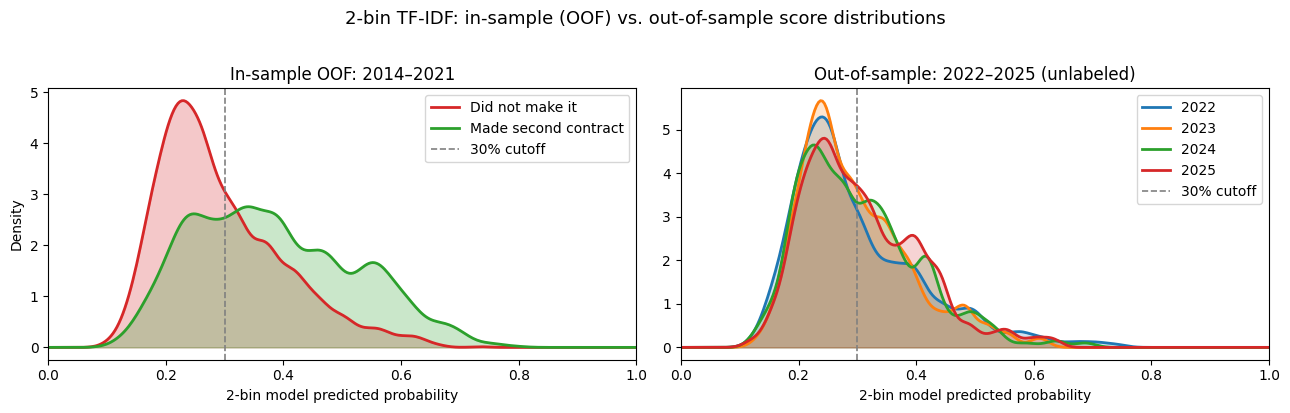

In [11]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: in-sample OOF by outcome ───────────────────────────────────────────
colors = {0: '#d62728', 1: '#2ca02c'}
labels = {0: 'Did not make it', 1: 'Made second contract'}
for outcome, grp in train_plot.groupby('y'):
    s = grp['oof_score'].dropna().values
    kde = gaussian_kde(s, bw_method=0.15)
    x = np.linspace(0, 1, 300)
    axes[0].fill_between(x, kde(x), alpha=0.25, color=colors[int(outcome)])
    axes[0].plot(x, kde(x), color=colors[int(outcome)], lw=2, label=labels[int(outcome)])
axes[0].axvline(0.3, color='gray', ls='--', lw=1.2, label='30% cutoff')
axes[0].set_title('In-sample OOF: 2014–2021', fontsize=12)
axes[0].set_xlabel('2-bin model predicted probability')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_xlim(0, 1)

# ── Right: out-of-sample by year ──────────────────────────────────────────────
year_colors = plt.cm.tab10.colors
for i, yr in enumerate(sorted(future_df['year'].unique())):
    s = future_df[future_df['year'] == yr]['bin_score'].dropna().values
    if len(s) < 5: continue
    kde = gaussian_kde(s, bw_method=0.15)
    x = np.linspace(0, 1, 300)
    c = year_colors[i % len(year_colors)]
    axes[1].fill_between(x, kde(x), alpha=0.2, color=c)
    axes[1].plot(x, kde(x), color=c, lw=2, label=str(yr))
axes[1].axvline(0.3, color='gray', ls='--', lw=1.2, label='30% cutoff')
axes[1].set_title('Out-of-sample: 2022–2025 (unlabeled)', fontsize=12)
axes[1].set_xlabel('2-bin model predicted probability')
axes[1].legend()
axes[1].set_xlim(0, 1)

plt.suptitle('2-bin TF-IDF: in-sample (OOF) vs. out-of-sample score distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Per-position violin plot

OOF predicted probability split by outcome for each position group, ordered by PR-AUC. Shows exactly where the model separates well and where it fails.

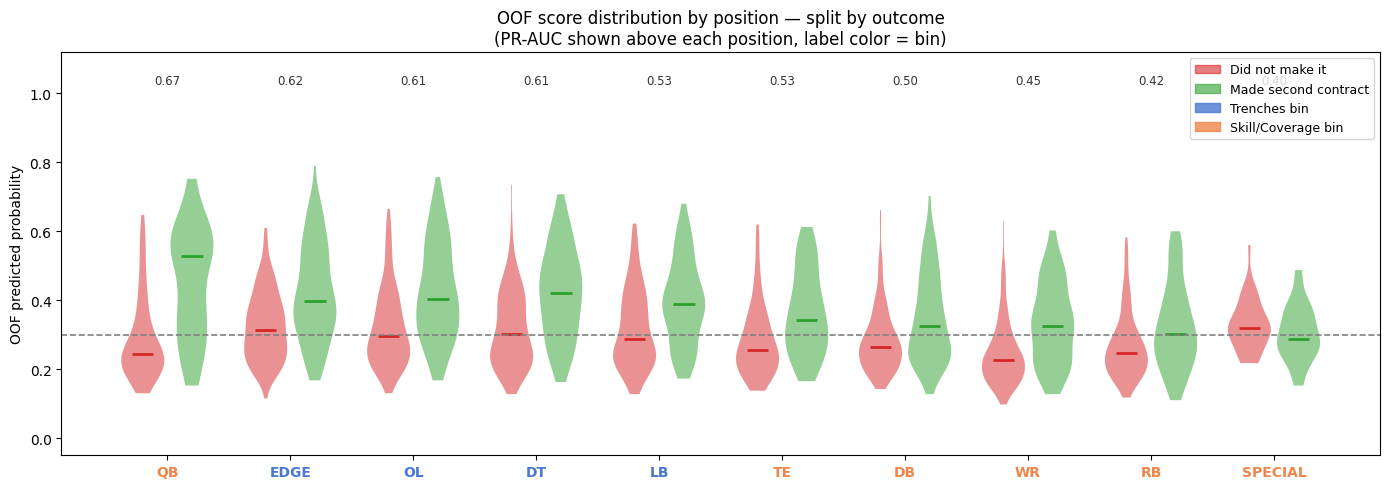

In [12]:
import matplotlib.patches as mpatches

# Order positions by PR-AUC descending (from per_bin_breakdown)
pos_order = (
    train_plot.groupby('Pos_Group')
    .apply(lambda g: average_precision_score(g['y'], g['oof_score']) if g['y'].nunique() == 2 else np.nan)
    .dropna()
    .sort_values(ascending=False)
    .index.tolist()
)

# Bin color per position for x-axis labels
bin_colors = {'trenches': '#4878d0', 'skill': '#ee854a'}

fig, ax = plt.subplots(figsize=(14, 5))

positions_data = []
for pos in pos_order:
    grp = train_plot[train_plot['Pos_Group'] == pos]
    made = grp[grp['y'] == 1]['oof_score'].values
    not_made = grp[grp['y'] == 0]['oof_score'].values
    positions_data.append((pos, made, not_made))

spacing = 2.0
x_ticks = []
x_labels = []

for i, (pos, made, not_made) in enumerate(positions_data):
    x_center = i * spacing

    # Not made (left violin)
    vl = ax.violinplot(not_made, positions=[x_center - 0.4], widths=0.7,
                       showmedians=True, showextrema=False)
    for pc in vl['bodies']:
        pc.set_facecolor('#d62728')
        pc.set_alpha(0.5)
    vl['cmedians'].set_color('#d62728')
    vl['cmedians'].set_linewidth(2)

    # Made it (right violin)
    vr = ax.violinplot(made, positions=[x_center + 0.4], widths=0.7,
                       showmedians=True, showextrema=False)
    for pc in vr['bodies']:
        pc.set_facecolor('#2ca02c')
        pc.set_alpha(0.5)
    vr['cmedians'].set_color('#2ca02c')
    vr['cmedians'].set_linewidth(2)

    # PR-AUC annotation
    grp = train_plot[train_plot['Pos_Group'] == pos]
    ap = average_precision_score(grp['y'], grp['oof_score'])
    ax.text(x_center, 1.02, f'{ap:.2f}', ha='center', va='bottom', fontsize=8.5, color='#333333')

    x_ticks.append(x_center)
    x_labels.append(pos)

ax.axhline(0.3, color='gray', ls='--', lw=1.2, label='30% cutoff')
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=10)

# Color x-axis labels by bin
for label, pos in zip(ax.get_xticklabels(), pos_order):
    b = BIN_MAP.get(pos, 'skill')
    label.set_color(bin_colors[b])
    label.set_fontweight('bold')

ax.set_ylabel('OOF predicted probability')
ax.set_ylim(-0.05, 1.12)
ax.set_title('OOF score distribution by position — split by outcome\n(PR-AUC shown above each position, label color = bin)', fontsize=12)

red_patch   = mpatches.Patch(color='#d62728', alpha=0.6, label='Did not make it')
green_patch = mpatches.Patch(color='#2ca02c', alpha=0.6, label='Made second contract')
blue_patch  = mpatches.Patch(color='#4878d0', alpha=0.8, label='Trenches bin')
orange_patch = mpatches.Patch(color='#ee854a', alpha=0.8, label='Skill/Coverage bin')
ax.legend(handles=[red_patch, green_patch, blue_patch, orange_patch],
          loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()